**Business Problem**

***Bank Customers who are likely to leave the bank can be identified early using ML ,allowing the bank to take retention actions***

**import necessary libraries**

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
import warnings
warnings.filterwarnings("ignore")

In [119]:
#load dataset
cust_churn=pd.read_csv("Churn_Modelling.csv")
cust_churn.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [120]:
#drop colums
cust_churn.drop(columns=["RowNumber","Surname","CustomerId"],axis="columns",inplace=True)

In [121]:
cust_churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [122]:
#check dataset
cust_churn["Exited"].value_counts(normalize=True)
#cust_churn.value_counts("Exited")#dataset is imbalanced

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [123]:
#check null values
cust_churn.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [124]:
#gender count
cust_churn["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

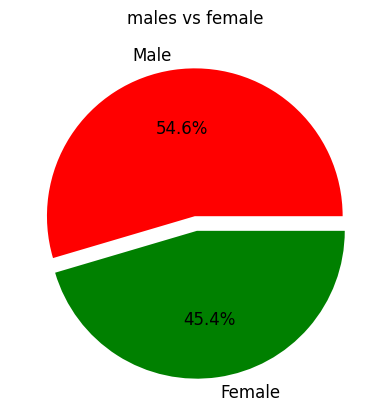

In [125]:
#visuavalize pie chart
colors=["red","green"]
explode=(0,0.1)
counts=cust_churn["Gender"].value_counts()
counts.plot(kind="pie",fontsize=12,colors=colors,explode=explode,autopct="%.1f%%")
plt.title("males vs female")
plt.show()


In [126]:
#geography column
cust_churn=pd.get_dummies(cust_churn,columns=["Geography"],drop_first=True,dtype=int)

In [127]:
#categorical to numerical change using map function
cust_churn["Gender"]=cust_churn["Gender"].map({"Male":0,"Female":1}).astype(int)

In [128]:
#summarizing dataset
print(cust_churn.info())
print(cust_churn.EstimatedSalary.describe())
print(cust_churn.shape)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Gender             10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  int64  
 11  Geography_Spain    10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB
None
count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199

In [129]:
#check duplicated values
cust_churn.duplicated().sum()

np.int64(0)

In [130]:
#segregating dataset
x=cust_churn.drop(["Exited"],axis=1)
x

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,1
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,39,5,0.00,2,1,0,96270.64,0,0
9996,516,0,35,10,57369.61,1,1,1,101699.77,0,0
9997,709,1,36,7,0.00,1,0,1,42085.58,0,0
9998,772,0,42,3,75075.31,2,1,0,92888.52,1,0


In [131]:
y=cust_churn["Exited"]
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64


In [132]:
#splitting dataset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)
x_train.shape


(8000, 11)

<Axes: ylabel='Age'>

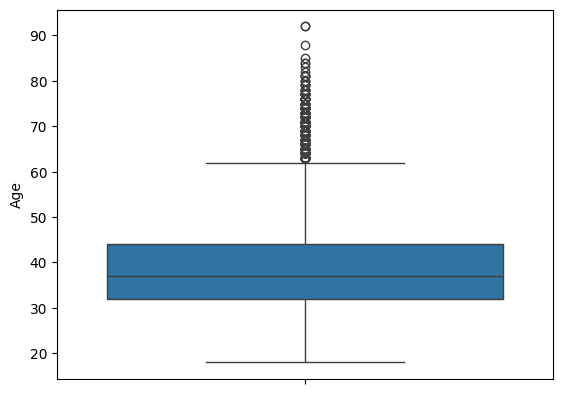

In [133]:
#exploratory data analysis
#check outliers
sns.boxplot(cust_churn["Age"])

In [134]:
numerical_cols=["CreditScore","Age","Tenure","Balance","NumOfProducts","EstimatedSalary"]
numerical_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

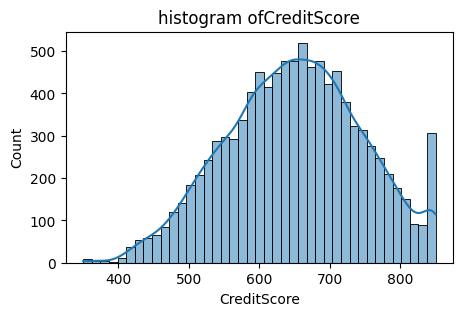

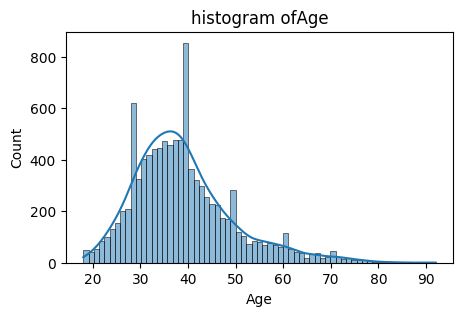

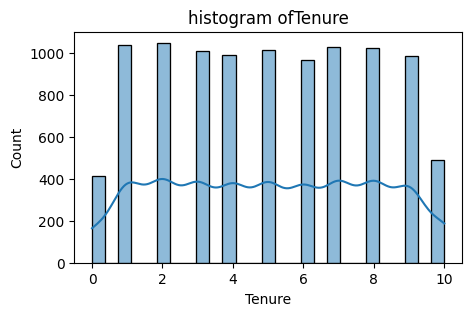

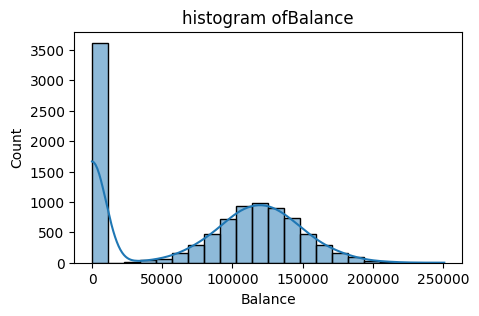

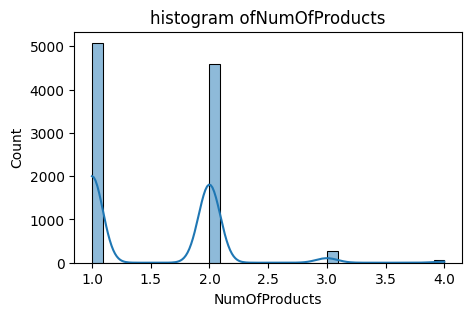

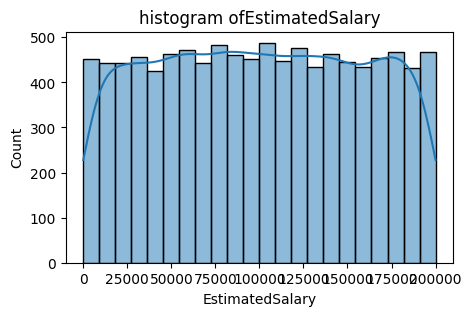

In [135]:
#distribution check
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(data=cust_churn,x=col,kde=True)#normal distribution
    plt.title(f"histogram of{col}")
    plt.show()

    #credit score distribution is slightly left skewed
    #age distribution is slightly right skewed

<Axes: xlabel='Age', ylabel='Balance'>

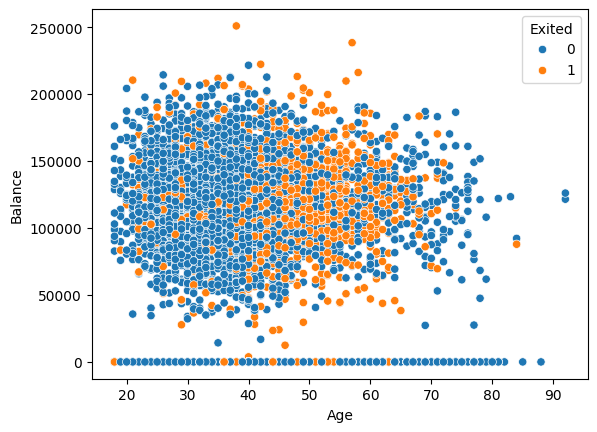

In [136]:
#scatter plot relationship between two features
sns.scatterplot(data=cust_churn,x="Age",y="Balance",hue="Exited")

In [137]:
#check correlation
cust_churn.corr()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
CreditScore,1.000000,0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780
Gender,0.002857,1.000000,0.027544,-0.014733,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512,0.024628,-0.016889
Age,-0.003965,0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685
Tenure,0.000842,-0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868
Balance,0.006268,-0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892
NumOfProducts,0.012238,0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039
HasCrCard,-0.005458,-0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480
IsActiveMember,0.025651,-0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732
EstimatedSalary,-0.001384,0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482
Exited,-0.027094,0.106512,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667


<Axes: >

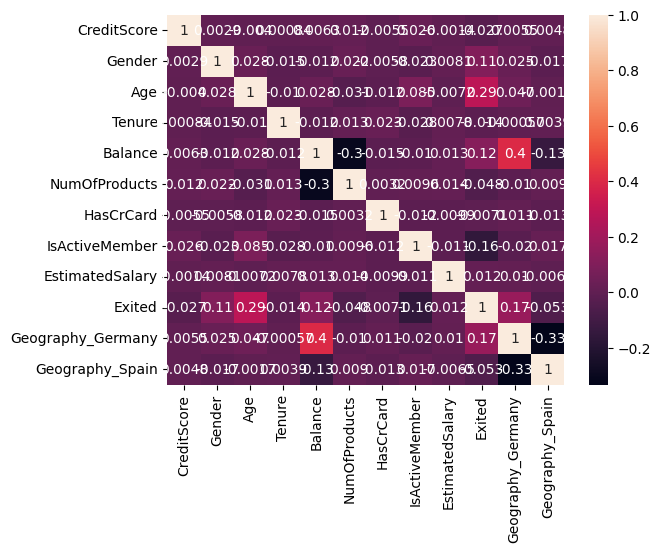

In [138]:
sns.heatmap(cust_churn.corr(),annot=True)

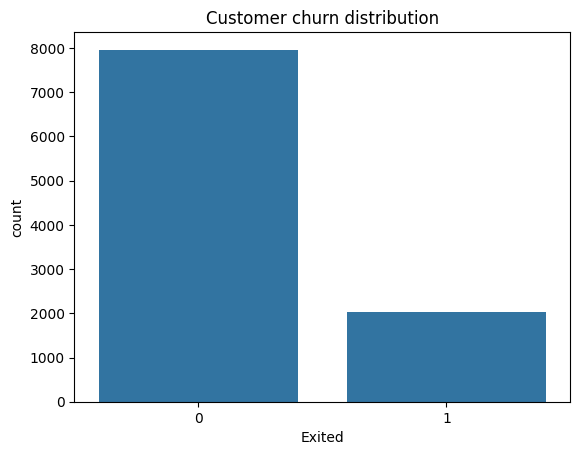

In [139]:
#target column countplot
sns.countplot(data=cust_churn,x="Exited")
plt.title("Customer churn distribution")
plt.show()

In [140]:
#using smote analysis
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_bal,y_train_bal=smote.fit_resample(x_train,y_train)
print(y_train.value_counts())
print(y_train_bal.value_counts())

Exited
0    6370
1    1630
Name: count, dtype: int64
Exited
0    6370
1    6370
Name: count, dtype: int64


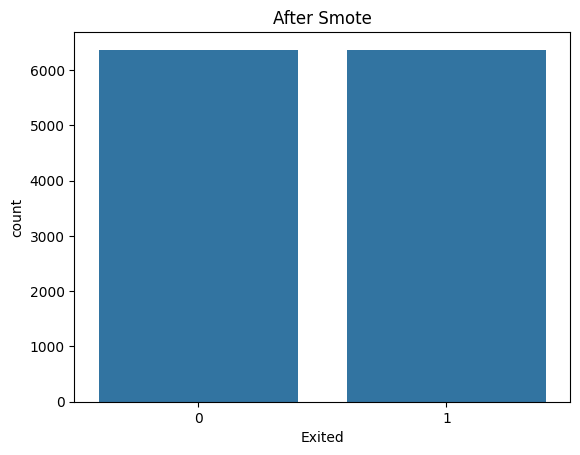

In [141]:
#after smote analysis
sns.countplot(x=y_train_bal)
plt.title("After Smote")
plt.show()

In [142]:
#feature scaling 
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_bal=sc.fit_transform(x_train_bal)
x_test=sc.transform(x_test)
x_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
8700,709,0,23,8,73314.04,2,1,0,63446.47,1,0
4438,672,0,68,0,126061.51,2,1,1,184936.77,1,0
4923,651,0,34,2,90355.12,2,0,0,193597.94,1,0
17,549,1,24,9,0.00,2,1,1,14406.41,0,1
5382,724,1,40,6,110054.45,1,1,1,86950.72,0,0
...,...,...,...,...,...,...,...,...,...,...,...
1751,541,0,29,7,127504.57,1,0,0,86173.92,0,0
8826,412,0,29,5,0.00,2,0,0,12510.53,0,0
1235,523,0,63,6,116227.27,1,1,1,119404.63,1,0
1286,579,0,37,5,152212.88,2,0,0,120219.14,0,1


In [143]:
#model training
LR=LogisticRegression(max_iter=1000)
LR.fit(x_train_bal,y_train_bal)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [144]:
#predict unseen data
y_pred=LR.predict(x_test)
print(y_pred)

[1 0 1 ... 0 0 0]


In [145]:
#evaluation metrics
accuracy_score(y_test,y_pred)

0.697

In [146]:
#try multiple algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
models={
    "DecisionTree":DecisionTreeClassifier(max_depth=5,random_state=42),
    "RandomForest":RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42),
    "XGB":XGBClassifier(n_estimators=200,random_state=42,eval_metric="logloss")
}
results=[]
for name,model in models.items():
    model.fit(x_train_bal,y_train_bal)
    y_pred=model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    pre=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    confu=confusion_matrix(y_test,y_pred)
    
    results.append([name,acc,pre,rec,f1,confu])
compare=pd.DataFrame(results,columns=["Model","Accuracy","Precison","Recall","f1_score","confusion_matrix"])
print(compare)

          Model  Accuracy  Precison    Recall  f1_score  \
0  DecisionTree    0.7705  0.458333  0.702703  0.554801   
1  RandomForest    0.7965  0.500000  0.658477  0.568399   
2           XGB    0.7960  0.498965  0.592138  0.541573   

            confusion_matrix  
0  [[1255, 338], [121, 286]]  
1  [[1325, 268], [139, 268]]  
2  [[1351, 242], [166, 241]]  


In [147]:
print(x_train_bal.mean())

1.9469702478370093e-17


In [148]:
#cross validation
from sklearn.model_selection import cross_val_score
score=cross_val_score(model,x_train_bal,y_train_bal,cv=5,scoring="f1")
print(f"F1 scores:{score}")
print(f"Average:{score.mean():.3f}")

F1 scores:[0.75098468 0.8594784  0.88821523 0.89209726 0.88464419]
Average:0.855


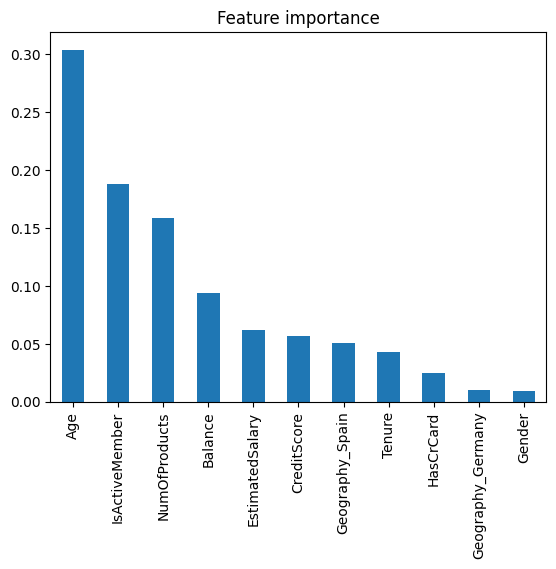

In [149]:
feat_map=pd.Series(models["RandomForest"].feature_importances_,index=x.columns).sort_values(ascending=False)
feat_map.plot(kind="bar")
plt.title("Feature importance")
plt.show()

In [150]:
import pickle
best_model=models["RandomForest"]
pickle.dump(best_model,open("model.pkl","wb"))

In [151]:
model=pickle.load(open("model.pkl","rb"))

In [152]:
pickle.dump(sc,open("scaler.pkl","wb"))

In [153]:
sc_load=pickle.load(open("scaler.pkl","rb"))